# NeuroSegment-BraTS: Treinamento do Modelo (Deep Learning)

**Notebook 4:** Modelagem e Experimentação

Nesta etapa, instanciamos a arquitetura da rede neural, definimos os parâmetros de otimização e executamos o ciclo de treinamento.

**Metodologia Experimental:**
*   **Modelo:** U-Net 3D (arquitetura padrão ouro para segmentação médica volumétrica).
*   **Função de Perda:** `DiceCELoss`. Uma combinação da *Cross-Entropy* (para classificação geral) com a *Dice Loss* (para otimizar o ganho sobre o desbalanceamento das classes tumorais).
*   **Otimizador:** Adam, que se ajusta bem a gradientes esparsos.
*   **Gestão de Hardware:** Como o sistema possui restrições de memória (16GB RAM/VRAM), o treinamento será feito em "Patches" (blocos menores de 96x96x96 gerados no *DataLoader*) e a validação será reconstruída via `SlidingWindowInferer`.

## 1. Importações e Inicialização

In [1]:
import optuna
import os
import torch
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinamento rodando no dispositivo: {device}")

if device.type == 'cuda':
    torch.cuda.empty_cache()

# Post-processing para validação
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

c:\Users\Beatriz\Documents\UFRPE\Projetos\AM\NeuroSegment-BraTS-MONAI\venv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Treinamento rodando no dispositivo: cuda


In [2]:
from tqdm.notebook import tqdm

def train_epoch(model, optimizer, loss_fn, dataloader, device):
    """Treina o modelo por 1 época. Retorna a loss média."""
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in dataloader:
        step += 1
        inputs = batch_data['image'].to(device)
        labels = batch_data['label'].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / step

def validate(model, dataloader, device, roi_size=(96, 96, 96)):
    """Avalia o modelo no conjunto de validação. Retorna o Dice médio."""
    model.eval()
    post_pred = AsDiscrete(argmax=True, to_onehot=4)
    post_label = AsDiscrete(to_onehot=4)
    dice = DiceMetric(include_background=False, reduction='mean')
    with torch.no_grad():
        for val_data in dataloader:
            val_inputs = val_data['image'].to(device)
            val_labels = val_data['label'].to(device)
            val_outputs = sliding_window_inference(
                inputs=val_inputs, roi_size=roi_size, sw_batch_size=4, predictor=model
            )
            val_outputs_list = [post_pred(i) for i in val_outputs]
            val_labels_list = [post_label(i) for i in val_labels]
            dice(y_pred=val_outputs_list, y=val_labels_list)
    result = dice.aggregate().item()
    dice.reset()
    return result

## 2. Ingestão do Pipeline de Dados
Abaixo, conectamos este notebook aos iteradores criados no Notebook 3.

In [3]:
import sys
sys.path.append('../')
from src.data_pipeline import get_dataloaders

# 1. Ingestão do Pipeline
train_loader, val_loader = get_dataloaders()
print("DataLoaders carregados com sucesso no Notebook 4!")

# Validando a conexão (assumindo que train_loader e val_loader estão definidos no kernel)
test_batch = next(iter(train_loader))
print(f"Shape de entrada da imagem: {test_batch['image'].shape}")
# Esperado: (Batch, Canais, X, Y, Z) -> ex: (2, 4, 96, 96, 96)

Total de pacientes carregados na tubulação: 368
DataLoaders carregados com sucesso no Notebook 4!


c:\Users\Beatriz\Documents\UFRPE\Projetos\AM\NeuroSegment-BraTS-MONAI\venv2\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape de entrada da imagem: torch.Size([2, 4, 96, 96, 96])


## 3. Definição da Arquitetura (U-Net 3D) e Hiperparâmetros
Configuramos a U-Net para aceitar 4 canais de entrada (FLAIR, T1, T1ce, T2) e devolver predições para as nossas 4 classes de interesse (0, 1, 2, 4).

In [ ]:
# 1. O Modelo: U-Net Tridimensional
model = UNet(
    spatial_dims=3,             # Imagem 3D
    in_channels=4,              # 4 Modalidades (FLAIR, T1, T1ce, T2)
    out_channels=4,             # 4 Classes de saída (Fundo/Normal, NCR, ED, ET)
    channels=(16, 32, 64, 128, 256), # Número de filtros por camada (mantido leve por causa dos 16GB de VRAM)
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

# 2. A Função de Perda (Loss Function)
# Combina Softmax (CrossEntropy) com a métrica espacial (Dice)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# 3. O Otimizador
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

# 4. A Métrica de Avaliação Oficial (Dice Score)
# Mede a sobreposição entre a máscara da IA e o gabarito do médico
dice_metric = DiceMetric(include_background=False, reduction="mean")

## 4. Otimização de Hiperparâmetros com Optuna
Usamos o Optuna para buscar os melhores hiperparâmetros. Cada trial treina por 10 épocas e avalia o Dice na validação.

**Hiperparâmetros buscados (U-Net 3D):**
- `learning_rate`: taxa de aprendizado (escala logarítmica entre 1e-5 e 1e-3)
- `num_res_units`: número de residual units por camada (1, 2 ou 3) — afeta a profundidade da rede

In [5]:
import optuna

def objective_unet(trial):
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    num_res = trial.suggest_int('num_res_units', 1, 3)

    model_trial = UNet(
        spatial_dims=3, in_channels=4, out_channels=4,
        channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2), num_res_units=num_res,
    ).to(device)

    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)
    loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)

    # DataLoader com num_workers=0 para evitar deadlock no Jupyter
    from monai.data import DataLoader as _MDL
    train_loader_opt = _MDL(train_loader.dataset, batch_size=1, shuffle=True, num_workers=0)
    val_loader_opt = _MDL(val_loader.dataset, batch_size=1, num_workers=0)

    for epoch in range(10):
        loss = train_epoch(model_trial, optimizer_trial, loss_fn, train_loader_opt, device)
        print(f'  Trial {trial.number} | Época {epoch+1}/10 | Loss: {loss:.4f}')

    result = validate(model_trial, val_loader_opt, device)

    del model_trial, optimizer_trial
    del train_loader_opt, val_loader_opt
    torch.cuda.empty_cache()

    return result

study = optuna.create_study(direction='maximize')
study.optimize(objective_unet, n_trials=10, show_progress_bar=True)

[I 2026-05-08 02:46:26,904] A new study created in memory with name: no-name-bd79f846-f19d-476a-92c8-d932ed6b6e33
  0%|          | 0/10 [00:00<?, ?it/s]

  Trial 0 | Época 1/10 | Loss: 2.2484
  Trial 0 | Época 2/10 | Loss: 1.9512
  Trial 0 | Época 3/10 | Loss: 1.6902
  Trial 0 | Época 4/10 | Loss: 1.4075
  Trial 0 | Época 5/10 | Loss: 1.1388
  Trial 0 | Época 6/10 | Loss: 0.9679
  Trial 0 | Época 7/10 | Loss: 0.8652
  Trial 0 | Época 8/10 | Loss: 0.7914
  Trial 0 | Época 9/10 | Loss: 0.7406
  Trial 0 | Época 10/10 | Loss: 0.6923


Best trial: 0. Best value: 0.610112:  10%|█         | 1/10 [24:14<3:38:06, 1454.06s/it]

[I 2026-05-08 03:10:40,965] Trial 0 finished with value: 0.6101120114326477 and parameters: {'learning_rate': 2.5257257113701934e-05, 'num_res_units': 3}. Best is trial 0 with value: 0.6101120114326477.
  Trial 1 | Época 1/10 | Loss: 1.2290
  Trial 1 | Época 2/10 | Loss: 0.7244
  Trial 1 | Época 3/10 | Loss: 0.6144
  Trial 1 | Época 4/10 | Loss: 0.5627
  Trial 1 | Época 5/10 | Loss: 0.5279
  Trial 1 | Época 6/10 | Loss: 0.4874
  Trial 1 | Época 7/10 | Loss: 0.4625
  Trial 1 | Época 8/10 | Loss: 0.4502
  Trial 1 | Época 9/10 | Loss: 0.4351
  Trial 1 | Época 10/10 | Loss: 0.4234


Best trial: 1. Best value: 0.707009:  20%|██        | 2/10 [48:04<3:12:03, 1440.38s/it]

...

[I 2026-05-08 05:55:01,391] Trial 7 finished with value: 0.6484853029251099 and parameters: {'learning_rate': 3.7125907648274276e-05, 'num_res_units': 2}. Best is trial 1 with value: 0.707008957862854.
  Trial 8 | Época 1/10 | Loss: 1.5280
  Trial 8 | Época 2/10 | Loss: 0.8569
  Trial 8 | Época 3/10 | Loss: 0.6770
  Trial 8 | Época 4/10 | Loss: 0.5928
  Trial 8 | Época 5/10 | Loss: 0.5349
  Trial 8 | Época 6/10 | Loss: 0.5062
  Trial 8 | Época 7/10 | Loss: 0.4855
  Trial 8 | Época 8/10 | Loss: 0.4595
  Trial 8 | Época 9/10 | Loss: 0.4443
  Trial 8 | Época 10/10 | Loss: 0.4293


Best trial: 1. Best value: 0.707009:  90%|█████████ | 9/10 [3:31:50<23:18, 1398.25s/it]

[I 2026-05-08 06:18:17,166] Trial 8 finished with value: 0.7054517269134521 and parameters: {'learning_rate': 0.00012113480220472284, 'num_res_units': 1}. Best is trial 1 with value: 0.707008957862854.
  Trial 9 | Época 1/10 | Loss: 1.4635
  Trial 9 | Época 2/10 | Loss: 0.8392
  Trial 9 | Época 3/10 | Loss: 0.7078
  Trial 9 | Época 4/10 | Loss: 0.6015
  Trial 9 | Época 5/10 | Loss: 0.5339
  Trial 9 | Época 6/10 | Loss: 0.4915
  Trial 9 | Época 7/10 | Loss: 0.4677
  Trial 9 | Época 8/10 | Loss: 0.4508
  Trial 9 | Época 9/10 | Loss: 0.4383
  Trial 9 | Época 10/10 | Loss: 0.4306


Best trial: 1. Best value: 0.707009: 100%|██████████| 10/10 [3:55:23<00:00, 1412.34s/it]

[I 2026-05-08 06:41:50,264] Trial 9 finished with value: 0.6896207928657532 and parameters: {'learning_rate': 0.00013637602324965652, 'num_res_units': 2}. Best is trial 1 with value: 0.707008957862854.


C:\Users\Beatriz\AppData\Local\Temp\ipykernel_13536\487155348.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis_plot.plot_optimization_history(study)


AttributeError: 'Axes' object has no attribute 'gca'

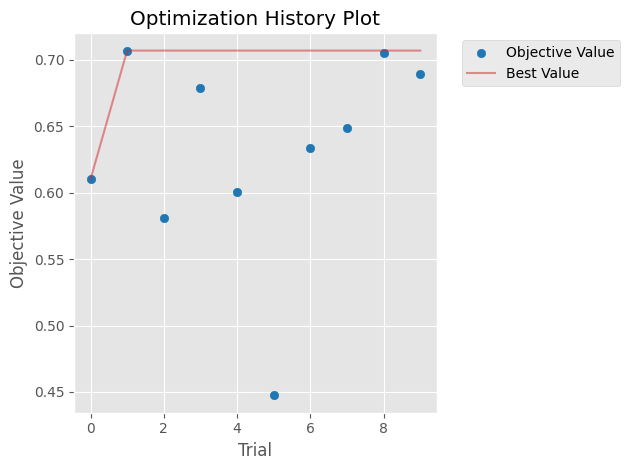

In [6]:
import optuna.visualization.matplotlib as vis_plot

fig = vis_plot.plot_optimization_history(study)
fig.gca().set_title('U-Net 3D — Histórico de Otimização')
plt.tight_layout()
plt.show()

fig2 = vis_plot.plot_param_importances(study)
plt.tight_layout()
plt.show()

print('=' * 50)
print('Melhores hiperparâmetros (U-Net 3D):')
print('=' * 50)
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f'  {key}: {value:.6f}')
    else:
        print(f'  {key}: {value}')
print(f'  Dice Score: {study.best_value:.4f}')
print('=' * 50)

In [7]:
# Redefinir modelo e otimizador com os melhores hiperparâmetros
learning_rate = study.best_params['learning_rate']
num_res_units = study.best_params['num_res_units']

model = UNet(
    spatial_dims=3, in_channels=4, out_channels=4,
    channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2), num_res_units=num_res_units,
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), learning_rate)
dice_metric = DiceMetric(include_background=False, reduction='mean')

print(f'U-Net 3D redefinida com lr={learning_rate:.6f}, num_res_units={num_res_units}')

U-Net 3D redefinida com lr=0.000232, num_res_units=2


## 4. O Ciclo de Treinamento e Validação
Executamos o treinamento iterativo. A cada *batch*, o modelo tenta segmentar o tumor, calcula o erro e ajusta seus pesos. Ao final de cada época, rodamos uma etapa de validação (sem aprender) para medir a performance real.

In [11]:
from tqdm import tqdm
# Configurações do Loop
max_epochs = 100
val_interval = 4

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

print('INICIANDO O TREINAMENTO...')

for epoch in tqdm(range(max_epochs), desc='Treinamento U-Net 3D'):
    # === MODO DE TREINO ===
    epoch_loss = train_epoch(model, optimizer, loss_function, train_loader, device)
    epoch_loss_values.append(epoch_loss)

    # === MODO DE VALIDAÇÃO ===
    if (epoch + 1) % val_interval == 0:
        metric = validate(model, val_loader, device)
        metric_values.append(metric)
        print(f'\n>>> Época {epoch+1}/{max_epochs} | Loss: {epoch_loss:.4f} | Dice: {metric:.4f}')

        if metric > best_metric:
            best_metric = metric
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join('../models', 'best_metric_model_Unet_3D.pth'))
            print('Novo recorde! Modelo salvo no disco.')

print(f'\nTREINAMENTO CONCLUÍDO! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}')

INICIANDO O TREINAMENTO...






Exception ignored in: <function tqdm.__del__ at 0x000001CBFFC39940>
Traceback (most recent call last):
  File "c:\Users\Beatriz\Documents\UFRPE\Projetos\AM\NeuroSegment-BraTS-MONAI\venv2\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Beatriz\Documents\UFRPE\Projetos\AM\NeuroSegment-BraTS-MONAI\venv2\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'




>>> Época 4/100 | Loss: 0.5305 | Dice: 0.6457
Novo recorde! Modelo salvo no disco.



>>> Época 8/100 | Loss: 0.4343 | Dice: 0.6759
Novo recorde! Modelo salvo no disco.



>>> Época 12/100 | Loss: 0.3993 | Dice: 0.7306
Novo recorde! Modelo salvo no disco.


...


>>> Época 88/100 | Loss: 0.2815 | Dice: 0.7933
Novo recorde! Modelo salvo no disco.



>>> Época 92/100 | Loss: 0.2780 | Dice: 0.7973
Novo recorde! Modelo salvo no disco.



>>> Época 96/100 | Loss: 0.2756 | Dice: 0.8003
Novo recorde! Modelo salvo no disco.






Treinamento U-Net 3D: 100%|██████████| 100/100 [1:56:00<00:00, 69.61s/it]


>>> Época 100/100 | Loss: 0.2757 | Dice: 0.7900

TREINAMENTO CONCLUÍDO! Melhor Dice: 0.8003 na época 96


## 5. Curvas de Aprendizado
Visualização da evolução do loss de treino e do Dice de validação ao longo das épocas.

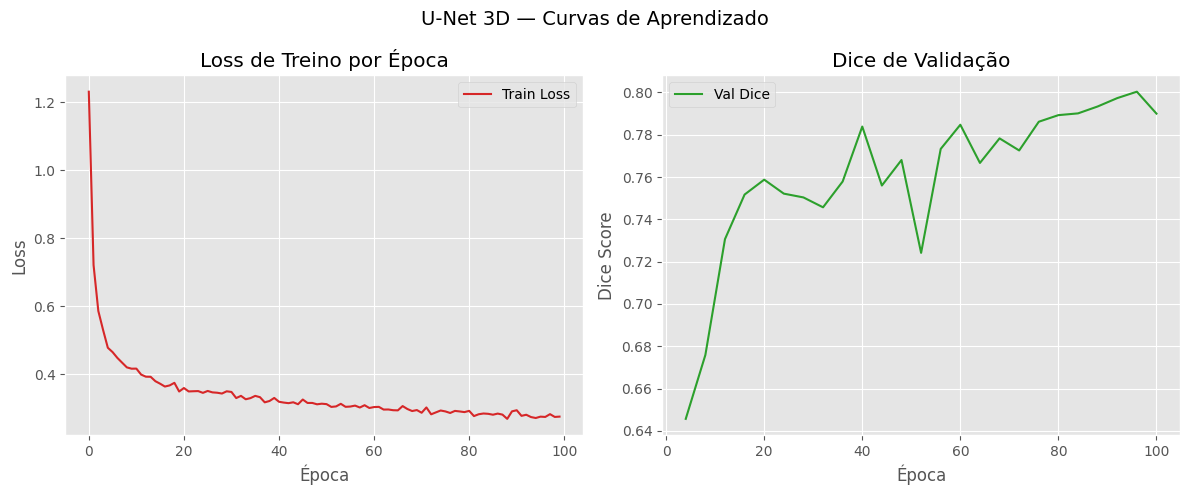

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epoch_loss_values, label='Train Loss', color='tab:red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss de Treino por Época')
ax1.legend()

val_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
ax2.plot(val_epochs, metric_values, label='Val Dice', color='tab:green')
ax2.set_xlabel('Época')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice de Validação')
ax2.legend()

plt.suptitle('U-Net 3D — Curvas de Aprendizado', fontsize=14)
plt.tight_layout()
plt.savefig('../models/unet3d_learning_curves.png', dpi=150)
plt.show()

## 6. Avaliação Detalhada do Melhor Modelo
Carregamos o melhor checkpoint e calculamos métricas detalhadas por classe na base de validação:
- **Dice Score** por classe (NCR, ED, ET)
- **Hausdorff Distance 95** por classe (métrica oficial BraTS)
- **Sensitivity** e **Specificity** por classe

| Métrica | O que mede | Interpretação |
|---------|-----------|---------------|
| **Dice** | Sobreposição entre predição e gabarito | 0–1, maior = melhor |
| **HD95** | Hausdorff Distance 95th percentile — pior distância de fronteira | mm, menor = melhor |
| **Sensitivity** | % de voxels tumorais corretamente detectados | 0–1, maior = melhor |
| **Specificity** | % de voxels saudáveis corretamente identificados | 0–1, maior = melhor |


In [13]:
from monai.metrics import DiceMetric, HausdorffDistanceMetric, ConfusionMatrixMetric

# Carregar o melhor modelo salvo
best_model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)
best_model.load_state_dict(torch.load(os.path.join('../models', 'best_metric_model_Unet_3D.pth'), weights_only=True))
print('Modelo U-Net 3D carregado com sucesso!')
best_model.eval()

# Métricas por classe
dice_per_class = DiceMetric(include_background=False, reduction="mean_batch")
hd95_per_class = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean_batch")
sensitivity_metric = ConfusionMatrixMetric(include_background=False, metric_name='sensitivity', reduction='mean_batch')
specificity_metric = ConfusionMatrixMetric(include_background=False, metric_name='specificity', reduction='mean_batch')

post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data['image'].to(device)
        val_labels = val_data['label'].to(device)

        val_outputs = sliding_window_inference(
            inputs=val_inputs, roi_size=(128, 128, 128), sw_batch_size=1, predictor=best_model
        )

        val_outputs_list = [post_pred(i) for i in val_outputs]
        val_labels_list = [post_label(i) for i in val_labels]

        dice_per_class(y_pred=val_outputs_list, y=val_labels_list)
        hd95_per_class(y_pred=val_outputs_list, y=val_labels_list)
        sensitivity_metric(y_pred=val_outputs_list, y=val_labels_list)
        specificity_metric(y_pred=val_outputs_list, y=val_labels_list)

# Agregar resultados
dice_scores = dice_per_class.aggregate()
hd95_scores = hd95_per_class.aggregate()
sens_raw = sensitivity_metric.aggregate()
spec_raw = specificity_metric.aggregate()

# ConfusionMatrixMetric com mean_batch retorna lista de tensores (cada um com C elementos)
# Flatten para 1D: ex: [tensor([a,b,c])] -> tensor([a,b,c])
def to_1d(x):
    if isinstance(x, list):
        x = torch.cat([t.flatten() for t in x])
    if isinstance(x, torch.Tensor) and x.dim() > 1:
        x = x.flatten()
    return x

sens_scores = to_1d(sens_raw)
spec_scores = to_1d(spec_raw)

class_names = ['NCR (TC)', 'ED (WT)', 'ET']
header = '{:<12} {:>8} {:>10} {:>8} {:>8}'.format('Classe', 'Dice', 'HD95', 'Sens', 'Spec')
print(header)
print('-' * 50)
for i, name in enumerate(class_names):
    d = dice_scores[i].item() if hasattr(dice_scores[i], 'item') else float(dice_scores[i])
    h = hd95_scores[i].item() if hasattr(hd95_scores[i], 'item') else float(hd95_scores[i])
    s = sens_scores[i].item() if i < len(sens_scores) else 0.0
    sp = spec_scores[i].item() if i < len(spec_scores) else 0.0
    print('{:<12} {:>8.4f} {:>10.2f} {:>8.4f} {:>8.4f}'.format(name, d, h, s, sp))
print('-' * 50)
mean_dice = dice_scores.mean().item() if hasattr(dice_scores, 'mean') else float(dice_scores)
mean_hd95 = hd95_scores.mean().item() if hasattr(hd95_scores, 'mean') else float(hd95_scores)
print('{:<12} {:>8.4f} {:>10.2f}'.format('Média', mean_dice, mean_hd95))

Modelo U-Net 3D carregado com sucesso!


c:\Users\Beatriz\Documents\UFRPE\Projetos\AM\NeuroSegment-BraTS-MONAI\venv2\Lib\site-packages\monai\utils\deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
c:\Users\Beatriz\Documents\UFRPE\Projetos\AM\NeuroSegment-BraTS-MONAI\venv2\Lib\site-packages\monai\metrics\utils.py:327: UserWarning: the ground truth of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(
c:\Users\Beatriz\Documents\UFRPE\Projetos\AM\NeuroSegment-BraTS-MONAI\venv2\Lib\site-packages\monai\metrics\utils.py:332: UserWarning: the prediction of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


Classe           Dice       HD95     Sens     Spec
--------------------------------------------------
NCR (TC)       0.7489       6.65   0.8006   0.9992
ED (WT)        0.8269       5.00   0.9044   0.9967
ET             0.8540       4.87   0.8725   0.9996
--------------------------------------------------
Média          0.8100       5.51
